In [26]:
from pathlib import Path
import json
import shutil
import subprocess
import sys
import urllib.request
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import torch
from IPython.display import Image, Video, display
import gdown

In [ ]:
# In this notebook. I am gonne run the learning to paint project on two inputs: one normal photo and one public painting.

In [ ]:
notebook_directory = Path.cwd()
ffmpeg_path ="ffmpeg"

In [ ]:
# let's keep all fils in one place.

repo_directory = notebook_directory / 'LearningToPaint'
inputs_directory= notebook_directory / 'assertinputs'
videos_directory = notebook_directory / 'videos'
runs_directory = notebook_directory / 'runs'

for folder in [inputs_directory, videos_directory, runs_directory]:
    folder.mkdir(exist_ok=True)
print(f"cuda: {torch.cuda.is_available()}")

cuda: True


In [ ]:
# To avoid clone the repo every time, 
if not repo_directory.exists():
    subprocess.run(["git", "clone", "--depth", "1","https://github.com/hzwer/ICCV2019-LearningToPaint.git",str(repo_directory)],check=True)

repo at LearningToPaint


In [ ]:
# I download the two model files

weight_file_ids = {"renderer.pkl":'1-7dVdjCIZIxh8hHJnGTK-RA1-jL1tor4',
                   "actor.pkl":"1a3vpKgjCVXHON4P7wodqhCgCMPgg1KeR"}

for weight_name, drive_file_id in weight_file_ids.items():
    weight_path =repo_directory/weight_name

    if not weight_path.exists():
        gdown.download(id=drive_file_id, output=str(weight_path), quiet=True)

{'renderer.pkl'}
{'actor.pkl'}


In [ ]:
# I patch test.py because this repo was written for older pytorch.
# I am going to  save the test.py because i use the same file again later.
test_path = repo_directory / "baseline" / "test.py"

test_code = test_path.read_text()
test_code= test_code.replace("torch.load(args.renderer)", "torch.load(args.renderer, weights_only=False)")
test_code= test_code.replace("torch.load(args.actor)", "torch.load(args.actor, weights_only=False)")
test_path.write_text(test_code)

5893

In [ ]:
# Preparing two input images

photo_path = inputs_directory / "photo.jpg"
painting_path = inputs_directory / "painting.jpg"

# I copy my own image into the input folder first.
photo_source = next((notebook_directory.parent / "Third_exercise").rglob("978613.jpg"))
shutil.copy(photo_source, photo_path)

def read_json(api_url):
    return json.loads(urllib.request.urlopen(api_url).read())

# I use the met api because I need real painting image.
met_api = "https://collectionapi.metmuseum.org/public/collection/v1"
search_data = read_json(f"{met_api}/search?hasImages=true&medium=Paintings&q=landscape%20mountain")
object_ids = search_data["objectIDs"]

for object_id in object_ids[:50]:
    object_data = read_json(f"{met_api}/objects/{object_id}")
    image_url = object_data["primaryImageSmall"] or object_data['primaryImage']
# I save the first usable painting and stop searching
    if object_data['isPublicDomain'] and image_url:
        painting_path.write_bytes(urllib.request.urlopen(image_url).read())
        print(f"painting: {object_data['title']}")
        break

print("photo: ready")


painting: Landscape
photo: ready


In [ ]:
# In this cell,  I am gonna run the same painting process twice.

# let's  create  run folder for each image.
def paint_image(image_path, run_name):
    run_dir = runs_directory / run_name
    output_dir = run_dir / 'output'

    shutil.rmtree(output_dir, ignore_errors=True)
    output_dir.mkdir(parents=True)

#  I pass the image path so test.py knows what image to paint.
    command = [sys.executable, str(repo_directory / "baseline" / "test.py"),"--max_step", '40',
              "--divide", "4","--renderer", str(repo_directory / "renderer.pkl"),"--actor", str(repo_directory / 'actor.pkl'),
              "--img", str(image_path),"--imgid", '0']
    subprocess.run(command, cwd=run_dir, check=True, capture_output=True)
    image_frames = sorted(output_dir.glob("generated*.png"))
    print(f"{run_name}: painted")
    return image_frames


photo_frames = paint_image(photo_path, "photo")
painting_frames = paint_image(painting_path, "painting")
# For debugging,  I used QWEN.

photo: painted
painting: painted


In [ ]:
# I create two videos the same way. one video is for the photo frames and one video is for the painting frames.

def making_video(video_name, image_frames):
    video_path = videos_directory / f"{video_name}.mp4"
    frame_pattern = image_frames[0].parent / "generated%d.png"
# I keep the video size at 512 by 512.
# I use libx264 because it create normal mp4 video
    subprocess.run([ffmpeg_path, "-y","-r", '10', "-f", "image2", '-i', str(frame_pattern),"-s", "512x512",
                    "-c:v", "libx264","-pix_fmt", "yuv420p",str(video_path)],check=True)
    
    print(f"{video_name} is ready")
    return video_path

photo_video_path = making_video('photo', photo_frames)
painting_video_path = making_video("painting", painting_frames)

photo is ready
painting is ready


Photo


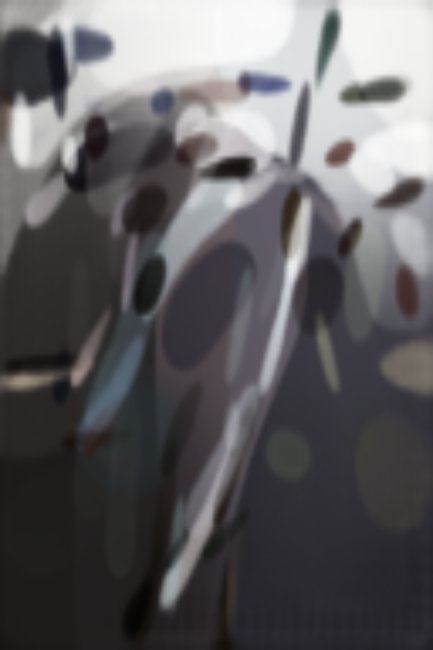

Painting


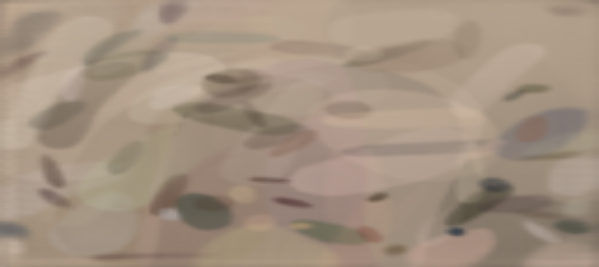

In [ ]:
for label, frames, video in [('Photo', photo_frames, photo_video_path),
                             ("Painting", painting_frames, painting_video_path)]:
    print(label)
    display(Image(filename=str(frames[-1]), width=400))
    display(Video(str(video), embed=True, width=512))

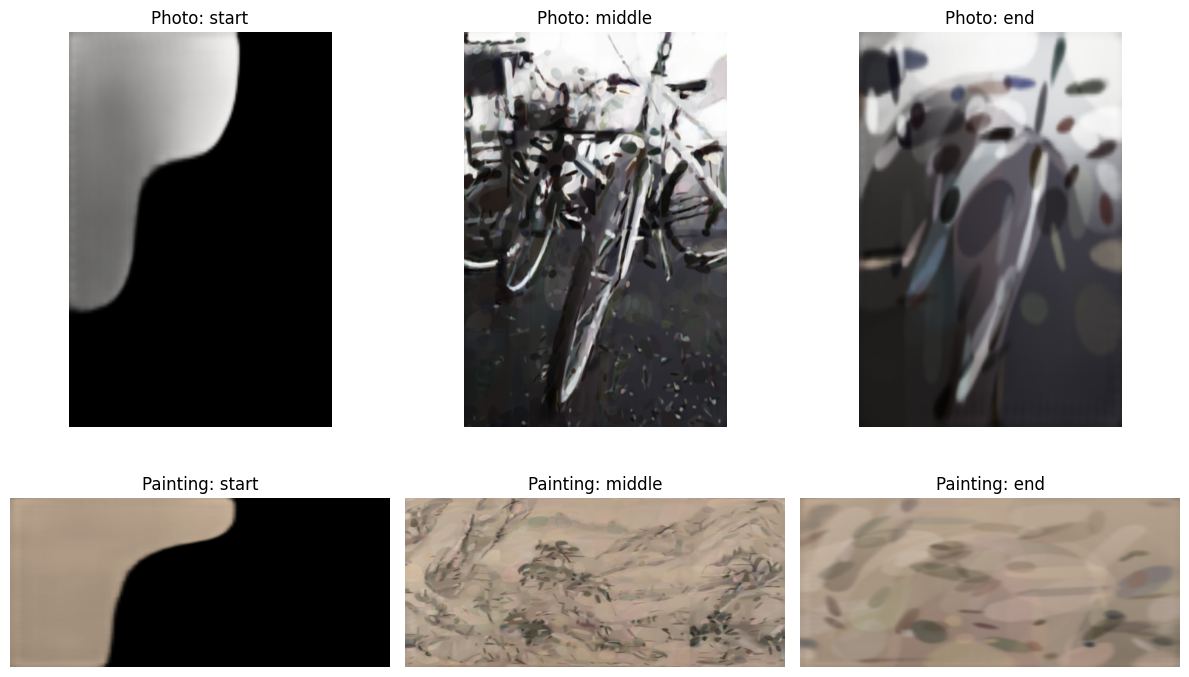

In [25]:
# I compare how the painting changes from start to end.
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for row, (label, frames) in enumerate([("Photo", photo_frames),("Painting", painting_frames)]):

    for ax, stage, idx in zip(axes[row], ["start", "middle", "end"], [0, len(frames) // 2, -1]):
        ax.imshow(mpimg.imread(str(frames[idx])))
        ax.set_title(f"{label}: {stage}")
        ax.axis("off")

plt.tight_layout()

In [ ]:
# Source: https://ffmpeg.org/ffmpeg.html
# https://metmuseum.github.io/
